# Preliminaries

In [386]:
import numpy as np
try:
    from numpy import trapezoid as trapz
except ImportError:
    from numpy import trapz  # NumPy < 2.0

import os, time

from mpi4py import MPI
from scipy.interpolate import LinearNDInterpolator
from petsc4py import PETSc

import dolfinx
from dolfinx.io import gmsh as gmshio, XDMFFile, VTXWriter
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
from dolfinx.fem import (
    Constant, Function, functionspace, dirichletbc,
    locate_dofs_topological, locate_dofs_geometrical,
    form, Expression, assemble_scalar,
)
from dolfinx.fem.petsc import NonlinearProblem, assemble_vector, set_bc

import ufl
from ufl import (inner, grad, div, sym, tr, det, inv, dot, sqrt,
                 indices, as_tensor, split, derivative,
                 Identity, SpatialCoordinate, FacetNormal,
                 TestFunction, TestFunctions, TrialFunction,
                 Measure, dx, ds, dS,
                 Jacobian, min_value)

import basix.ufl as basix_ufl

# DOLFIN_EPS no longer exists; use numpy's machine epsilon instead
DOLFIN_EPS = float(np.finfo(np.float64).eps)

In [387]:
from matplotlib import pyplot as plt
from matplotlib import tri, colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d
size = 18
params = {
    'legend.fontsize': size * 0.75,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{mathrsfs,bm}',
    'axes.labelsize': size,
    'axes.titlesize': size,
    'xtick.labelsize': size * 0.875,
    'ytick.labelsize': size * 0.875,
    'axes.titlepad': 25,
    'animation.embed_limit': 2**128,
}
plt.rcParams.update(params)

## Credit

Features enabled by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot and Claude, ca. Fall 2025&ndash;Spring 2026) include:
- refactoring previous version to [dolfinx](https://github.com/fenics/dolfinx)/next-gen FEniCS.
- Jupyter notebook format for easier on-the-fly analysis, 
- use of [gmsh](https://docs.fenicsproject.org/dolfinx/main/python/demos/demo_gmsh.html) for modern meshing and I/O,
- [BDF2](https://en.wikipedia.org/wiki/Backward_differentiation_formula#Specific_formulas) time stepping,
- pressure inlet as Neumann BC, 
- Carreau viscosity model for shear-thinning fluids,
- 2D-restricted neo-Hookean model with isochoric-volumetric splitting to handle strong compression of the solid,
- velocity-based damping in the solid for improved convergence to steady state,
- steady analytical solutions for benchmarking and comparisons,
- post-processing, benchmarks, and [Matplotlib](https://matplotlib.org/) visualizations.

Early version based heavily on David Kamensky's [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi).


If you want to run this solver as a standalone python script (stripping all Markdown comments, etc), run the following command in your terminal:

`
jupyter nbconvert ALE-FSIx_2D.ipynb --to python --PythonExporter.exclude_markdown=True
`

which creates the file `ALE-FSIx_2D.py`.

## Introduction

Sketch of the geometry and notation.

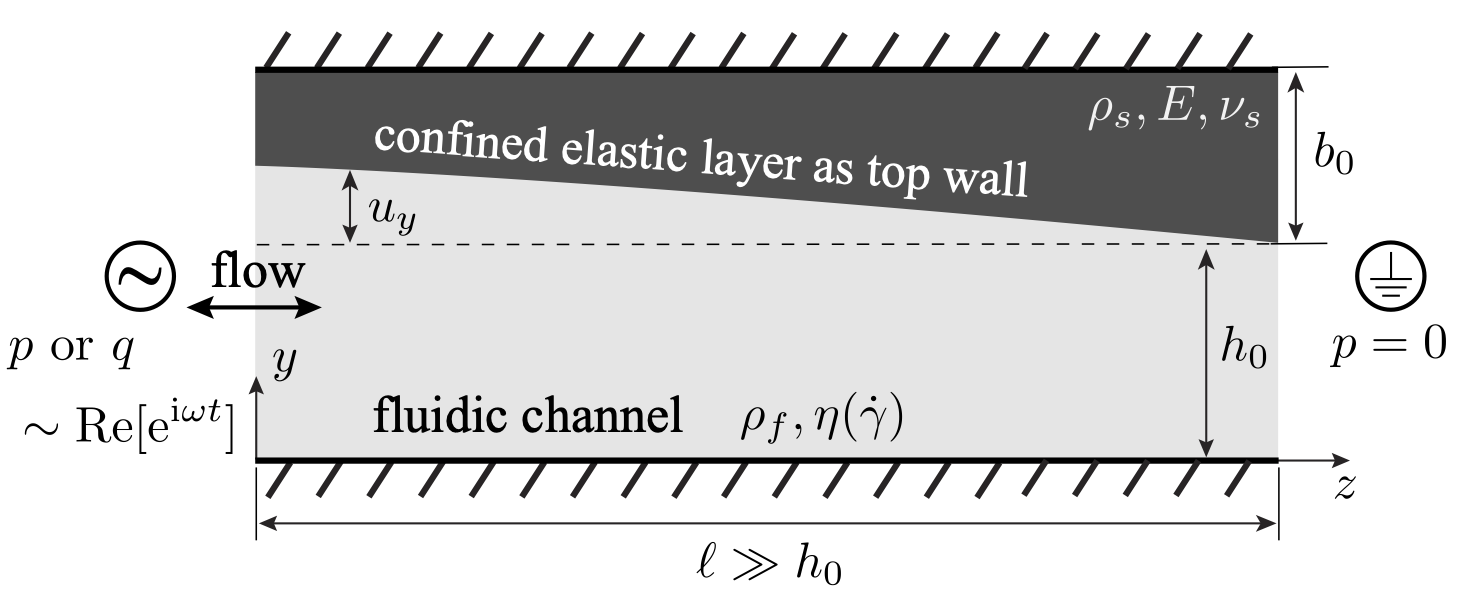

<span style="color: red">WARNING:</span> Carreau model is only implemented in the numerics. The theory relies on the power-law approximation &amp; Winkler-foundation elastic model.

# Problem setup

## General simulation settings

### Data storage

In [388]:
DataFolder = "not-ready-for-github/simulation_output/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output/


### Algorithmic settings

Shouldn't require changing.

In [389]:
LSIC          = False     # Least-squares incompressibility stabilization for fluid
BACKFLOW_STAB = True      # Backflow stabilization for fluid
SUPG          = False     # Streamline Upwind Petrov-Galerkin stabilization for fluid
                          # shouldn't needed for low Re flow or with Taylor-Hood elements

print("============================ INFO ============================")
print(f"SUPG stabilization:       {'ON' if SUPG else 'OFF'}")
print(f"LSIC stabilization:       {'ON' if LSIC else 'OFF'}")
print(f"Backflow stabilization:   {'ON' if BACKFLOW_STAB else 'OFF'}")
print("=============================================================")

============================ INFO ============================
SUPG stabilization:       OFF
LSIC stabilization:       OFF
Backflow stabilization:   ON


## General problem settings

### Parameters defining domain geometry

In [ ]:
b0 = 0.01
h0 = b0
l  = 50*h0

# Solid domain extents:
SOLID_TOP    = h0+b0
SOLID_BOTTOM = h0
SOLID_LEFT   = 0.0
SOLID_RIGHT  = l
# Combined domain size:
OMEGA_H      = h0+b0
OMEGA_W      = l

# Desired resolution of mesh:
N = 100 # 600
# Refine near inlet in SOLID domain only
inlet_refinement_solid_only = True
inlet_refinement = 0.33 # 1 = no refinement, 1/() times finer
# Refinement near fluid-solid interface
interface_refinement = 0.33 # 1 = no refinement, 1/() times finer
# Geometry-scale tolerance for subdomains:
d_tol = h0 * 1e-8

### Material properties (dimensional)

The solid is linearly elastic (with material constants $E_s$, $\nu_s$).

The fluid is a generalized Newtonian fluid with shear-thinning behavior described by the Carreau model:
\begin{align*}
     \eta(\dot{\gamma}) 
     &= \eta_{\infty} + \left(\eta_0-\eta_{\infty}\right) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \right\} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) |\lambda \dot{\gamma}|^{n-1} \right\}, \qquad |\lambda \dot{\gamma}| \gg 1 \\
     &= \eta_{0} |\lambda \dot{\gamma}|^{n-1}\qquad\qquad\;\;\; \beta \ll 1,\quad |\lambda \dot{\gamma}| \gg 1.
\end{align*}

In [391]:
# Elasticity model for real solid:
ELASTICITY_MODEL = "NEOH"  # "STVK" for Saint-Venant--Kirchhoff 
                           # "NEOH" for neo-Hookean, more robust than STVK

# Elastic solid's properties:
E_s        = 3e3                                 # Young's modulus
nu_s       = 0.45                                # Poisson ratio
mu_s_val   = E_s / (2 * (1 + nu_s))              # Shear modulus
K_val      = E_s / (3 * (1 - 2 * nu_s))          # Bulk modulus
rho_s0_val = 1e3                                 # Reference density of the solid
cs_val     = np.sqrt(mu_s_val / rho_s0_val)      # Shear wave speed
zeta       = 0.10                                # Damping ratio
cd_est     = 2.0 * zeta * cs_val / b0            # Estimated velocity-proportional damping (1/s)
                                                 # (to suppresses transients for steady simulations)
print(f"Try damping coeff ~ {cd_est:.3g} 1/s for damping factor = {zeta:.3g}")

# Fluid properties used to target desired dimensionless numbers:
rho_f_val     = 0.5                                   # Fluid density
eta_f_0_val   = 4.5   #10.0                           # Zero-shear viscosity
eta_f_inf_val = 2.e-4 #0.0                            # Infinite-shear viscosity
n_val         = 0.7   #0.36 #1.00                     # Power-law / shear-thinning index
lam_r_val     = 18.0  #0. 0                           # Char. shear-rate scale for thinning
m_plaw_val    = eta_f_0_val * lam_r_val**(n_val - 1)  # Power-law consistency index

Try damping coeff ~ 20.3 1/s for damping factor = 0.1


### Dimensionless numbers

To determine the scales and dimensionless numbers we need to pick the BC type here.

In [392]:
# Steady pressure BC magnitude (used when FLOW_OR_PRESSURE == "PRESSURE"):
p_amp_val        = 2e3
# Steady flow-rate magnitude (used when FLOW_OR_PRESSURE == "FLOW"):
q_amp_val        = 1e-3

# Choose flow- or pressure-controlled inlet forcing:
FLOW_OR_PRESSURE = "PRESSURE"  # "FLOW" or "PRESSURE"

In [393]:
# Choose characteristic scales consistently with the active inlet control mode.
# This keeps the nondimensional diagnostics comparable between FLOW and PRESSURE runs.
if FLOW_OR_PRESSURE == "FLOW":
    q_c   = q_amp_val
    v_c   = q_c / h0
    p_c   = m_plaw_val * l * (q_c**n_val) / h0**(2*n_val + 1)
    dp_rigid = float(2**(1 + 1/n_val) * (2 + 1/n_val)) * p_c
    q_rigid  = q_c
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c   = p_amp_val
    q_c   = ((p_c / l) * (h0**(2*n_val + 1) / m_plaw_val))**(1/n_val)
    v_c   = q_c / h0
    dp_rigid = p_c
    q_rigid  = q_c / float(2**(1 + 1/n_val) * (2 + 1/n_val))
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

In [394]:
omega = 0                                                     # Frequency (for oscillatory flow)

epsilon_f = h0/l                                              # Fluid (inverse) aspect ratio
epsilon_s = b0/l                                              # Solid (inverse) aspect ratio

C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s_val/l**2) # Incompressible foundation compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*(b0/mu_s_val)                   # Winkler foundation compliance
C_H = (nu_s-1/4)/(1-nu_s)*(b0**2/mu_s_val/l)                  # Horizontal component compliance
theta = float(C_I/C_w)
vartheta = float(C_H/C_w)
alpha = float(p_c/(h0/C_w))                                   # Compliance number

Wo = sqrt(h0**2 * omega/float(eta_f_0_val/rho_f_val))         # Womersley number

gamma = float(C_w*l*eta_f_0_val*omega/(epsilon_f*h0**2))      # Elastoviscous number

#Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/eta_f**2)      # Reynolds number
Re = float(epsilon_f * rho_f_val * v_c * h0/eta_f_0_val) 
#Re = float(Wo**2 * alpha/gamma)                              # Only if unsteady

beta = float(eta_f_inf_val/eta_f_0_val)                       # Carreau viscosity ratio
Cu = float(lam_r_val * v_c/h0)                                # Carreau number

print("============================ INFO ===========================")
print(f">>> Using {FLOW_OR_PRESSURE}-controlled BC & appropriate scales.")
print("-------------------------------------------------------------")
print(f"ε_f = {epsilon_f:.5f}")
print(f"ε_s = {epsilon_s:.5f}")
print(f"θ   = {theta:.5f}")
print(f"α   = {alpha:.5f} (compliance #)")
print(f"Wo  = {Wo:.5f} (Womersley #)")
print(f"γ   = {gamma:.5f} (Elastoviscous #)")
print(f"εRe = {Re:.5f} (Reynolds #)")
print(f"β   = {beta:.5f} (viscosity ratio)")
print(f"Cu  = {Cu:.5f} (Carreau #)")
if omega != 0 and cd_est != 0:
    print("-------------------------------------------------------------")
    print("WARNING: You're using damping for an oscillatory simulation!")
print("=============================================================")

============================ INFO ===========================
>>> Using PRESSURE-controlled BC & appropriate scales.
-------------------------------------------------------------
ε_f = 0.02000
ε_s = 0.02000
θ   = 0.00087
α   = 0.17576 (compliance #)
Wo  = 0.00000 (Womersley #)
γ   = 0.00000 (Elastoviscous #)
εRe = 0.00002 (Reynolds #)
β   = 0.00004 (viscosity ratio)
Cu  = 1408.45453 (Carreau #)


### Analytical solutions: for comparisons, etc

#### Rigid channel

Currently, implementing only the steady power-law 2D channel flow solution.

**TODO:** Implement oscillatory (Womersley) 2D channel flow solution for Newtonian case.

In [395]:
def p_rigid_py(x, y=0.0):
    # Rigid-channel pressure field.
    return (dp_rigid / l) * (l - x) if y < h0 + d_tol else 0.0

def v_rigid_py(x_arr):
    """
    Rigid-channel power-law velocity profile.
    x_arr : shape (2, N) array of spatial coords (from dolfinx interpolation)
    Returns shape (2, N) velocity array.
    """
    vals = np.zeros_like(x_arr)
    mask = x_arr[1] < h0 + d_tol
    y    = x_arr[1, mask]
    vals[0, mask] = (q_rigid / h0 * (2 + 1/n_val) / (1 + 1/n_val)
                     * (1 - np.abs(1 - 2*y/h0)**(1 + 1/n_val)))
    return vals

#### Compliant channel

Implementing Eq. (41) and related results from "[Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits](https://dx.doi.org/10.1088/1361-648X/ac327d)" (preprint [arXiv:2106.07164](https://arxiv.org/abs/2106.07164)):
$$
    %-\frac{dp}{d{z}} = \frac{2^{1+n}(2+1/n)^n m q^n}{[h_0 + \mathcal{C} p(z)]^{1+2n}w^n},
    -\frac{dp}{d{z}} = \frac{2^{1+n}(2+1/n)^n m q^n}{[h_0 + \mathcal{C} p(z)]^{1+2n}},\quad p(\ell) = 0,
$$
which can be integrated directly when $q$ is given (flow-rate control), or differentiated once and solved as 
$$
    \frac{d}{d{z}}\left\{ [h_0 + \mathcal{C} p(z)]^{1+2n} \frac{dp}{d{z}}  \right\} = 0,\quad p(0) = \Delta p,\quad p(\ell) = 0,
$$
when $\Delta p$ is given (pressure-drop control).

In [396]:
# Common factor in both the p_sh pressure formula (FLOW) and q_sh flux formula (PRESSURE).
nhat_factor = 2**(1 + n_val) * (2 + 1/n_val)**n_val

if FLOW_OR_PRESSURE == "FLOW":
    nhat = nhat_factor * (2 + 2*n_val)
    def p_sh_py(x, y=0.0):
        # Soft-hydraulic pressure (flow rate-controlled).
        return p_c / alpha * ((1 + nhat * alpha * (1 - x/l))**(1/(2 + 2*n_val)) - 1)
    q_sh = q_rigid

elif FLOW_OR_PRESSURE == "PRESSURE":
    def p_sh_py(x, y=0.0):
        # Soft-hydraulic pressure (pressure-controlled).
        arg = (1 + alpha)**(2 + 2*n_val) * (1 - x/l) + x/l
        return p_c / alpha * (arg**(1/(2 + 2*n_val)) - 1)

    # dp/dx at x=0 by direct differentiation of p_sh_py:
    #   p(x) = (p_c/α) · [(1+α)^s·(1-x/l) + x/l]^(1/s) − p_c/α,  s = 2+2n
    #   dp/dx|_{x=0} = (p_c/(α·l·s)) · (1+α)^(1−s) · (1 − (1+α)^s)
    #                = (p_c/(α·l·s)) · [(1+α)^{−(1+2n)} − (1+α)]
    # h(0) = h0 + C_w·p_sh(0) = h0 + C_w·p_c = h0·(1+α)  [since α = C_w·p_c/h0]
    dp_shdz0 = (p_c / (alpha * l * (2 + 2*n_val))) * ((1 + alpha)**(-(1 + 2*n_val)) - (1 + alpha))
    q_sh = ((-dp_shdz0)
            * (h0 * (1 + alpha))**(1 + 2*n_val) / m_plaw_val
            / nhat_factor)**(1/n_val)
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

## Derived simulation settings

### Domain and mesh

Gmsh-based geometry & mesh.

In [397]:
from build_gmsh_x import (
    build_gmsh_x,
    FLUID_FLAG, SOLID_FLAG,
    INTERFACE_TAG, WALL_B_TAG, WALL_T_TAG,
    INFLOW_TAG, OUTFLOW_TAG, WALL_L_TAG, WALL_R_TAG,
)

mesh, cell_tags, facet_tags = build_gmsh_x(
    N,
    [0.0, OMEGA_W, 0.0, OMEGA_H, SOLID_BOTTOM],
    DataFolder + "fsi_rect",
    inlet_refinement=inlet_refinement,
    inlet_refinement_solid_only=inlet_refinement_solid_only,
    interface_refinement=interface_refinement,
)

# Mesh-derived quantities
# NOTE: mesh.geometry().dim() → mesh.geometry.dim  (property, not method)
d   = mesh.geometry.dim
n_y = FacetNormal(mesh)
I   = Identity(d)

# Rename tags to match the variable names used throughout the original notebook:
INFLOW  = INFLOW_TAG
OUTFLOW = OUTFLOW_TAG

# Redefine constants (as dolfinx.fem.Constant, not just Python floats):
mu_s      = Constant(mesh, mu_s_val)
K         = Constant(mesh, K_val)
rho_s0    = Constant(mesh, rho_s0_val)
cd        = Constant(mesh, 1.0 * cd_est)

rho_f     = Constant(mesh, rho_f_val)
eta_f_0   = Constant(mesh, eta_f_0_val)
eta_f_inf = Constant(mesh, eta_f_inf_val)
n         = Constant(mesh, n_val)
lam_r     = Constant(mesh, lam_r_val)

p_amp = Constant(mesh, p_amp_val)
q_amp = Constant(mesh, q_amp_val)

# m_plaw: still a UFL expression involving Constants
m_plaw = eta_f_0 * lam_r**(n - 1.0)

Info    : Found interface curve 4: x = [-0.000000, 0.500000], y = 0.010000                                  
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.159006s, CPU 0.179263s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0598052s, CPU 0.095087s)
Info    : 2651 nodes 5674 elements
Info    : Writing 'not-ready-for-github/simulation_output/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output/fsi_rect.msh'


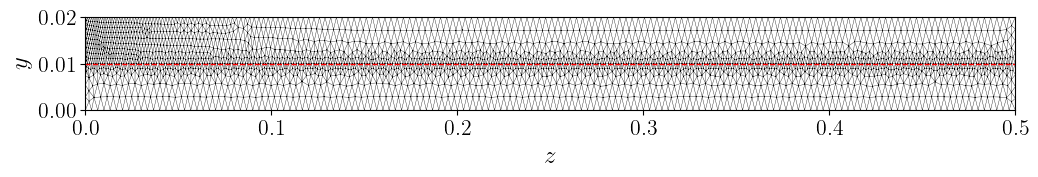

In [398]:
# Visualize the mesh (dolfinx: matplotlib triangulation instead of dolfin.plot):
coords = mesh.geometry.x                        # shape (n_pts, 3), z-column=0 for 2D
num_cells = mesh.topology.index_map(2).size_local
mesh.topology.create_connectivity(2, 0)
c2v = mesh.topology.connectivity(2, 0)
triangles = np.array([c2v.links(i) for i in range(num_cells)])

triang = tri.Triangulation(coords[:, 0], coords[:, 1], triangles)

fig, ax = plt.subplots(figsize=(12, 6))
ax.triplot(triang, linewidth=0.25, color='k')
ax.plot(np.linspace(0, l, 10), np.ones(10)*h0,
        linestyle='dashed', linewidth=1.0, color='red')
ax.set_aspect('auto')
ax.set_xlim(0, l)
ax.set_ylim(0, h0 + b0)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$y$')
plt.gca().set_aspect(2.5/1)
plt.show()

In [399]:
# Define subdomain locators for BCs and integration measures
def wall_b_locator(x):
    return x[1] < d_tol

def wall_t_locator(x):
    return x[1] > SOLID_TOP - d_tol

def wall_l_locator(x):
    return np.logical_and(x[0] < d_tol, x[1] > SOLID_BOTTOM - d_tol)

def wall_r_locator(x):
    return np.logical_and(x[0] > SOLID_RIGHT - d_tol, x[1] > SOLID_BOTTOM - d_tol)
 
def inflow_locator(x):
    return np.logical_and(x[0] < d_tol, x[1] < SOLID_BOTTOM + d_tol)

def outflow_locator(x):
    return np.logical_and(x[0] > OMEGA_W - d_tol, x[1] < SOLID_BOTTOM + d_tol)

def solid_closure_locator(x):
    return (np.logical_and(x[1] > SOLID_BOTTOM - d_tol, x[1] < SOLID_TOP + d_tol) &
            np.logical_and(x[0] > SOLID_LEFT - d_tol,   x[0] < SOLID_RIGHT + d_tol))

# IMPORTANT: use y > SOLID_BOTTOM to include solid lateral wall nodes
# (x≈0 and x≈l, y>h0).  solid_interior_locator excludes those nodes and
# leaves their pressure DOFs unconstrained, making the Jacobian singular.
# Interface nodes (y = SOLID_BOTTOM = h0) are deliberately excluded — their
# pressure is the fluid pressure (determined by the flow equations).
def solid_p_locator(x):
    return x[1] > SOLID_BOTTOM + d_tol

# def solid_interior_locator(x):
#     return (np.logical_and(x[1] > SOLID_BOTTOM + d_tol, x[1] < SOLID_TOP + d_tol) &
#             np.logical_and(x[0] > SOLID_LEFT + d_tol,   x[0] < SOLID_RIGHT - d_tol))

In [400]:
# Define measures for integration, with appropriate quadrature degree.
qd = 4   # quadrature degree (steady solver uses 5; 4 balances accuracy vs speed)
dx = Measure("dx", domain=mesh, subdomain_data=cell_tags,
             metadata={"quadrature_degree": qd})
ds = Measure("ds", domain=mesh, subdomain_data=facet_tags,
             metadata={"quadrature_degree": qd})
dS = Measure("dS", domain=mesh, subdomain_data=facet_tags,
             metadata={"quadrature_degree": qd})

# Shorthand used throughout the variational forms (unchanged from original):
dX   = dx(SOLID_FLAG)   # solid volume integral
dy   = dx               # reference-config volume integral (fluid + solid)
ds_y = ds               # reference-config surface integral

### Time stepping details

Time stepping details come after setting everything else, so that we can properly set them for the _given_ problem.

Time integration uses a **BDF2 (second-order backward difference) scheme**, with a single BDF1 (backward Euler) startup step to bootstrap the two-level history.

The BDF2 time derivative approximation at step $n+1$ is:
$$
    \frac{\partial \mathbf{v}}{\partial t}\bigg|^{n+1} \approx \frac{a_0\mathbf{v}^{n+1} + a_1\mathbf{v}^{n} + a_2\mathbf{v}^{n-1}}{\Delta t}.
$$

The solid kinematic constraint $\dot{u} = v$ is integrated with the same BDF stencil:
$$
    \mathbf{u}^{n+1} = \frac{\Delta t\, \mathbf{v}^{n+1} - a_1 \hat{\mathbf{u}}^n - a_2 \hat{\mathbf{u}}^{n-1}}{a_0}.
$$

**Why BDF2 over backward Euler?** 

BE introduces $O(\omega^2 \Delta t^2)$ artificial amplitude damping per step on oscillatory modes, which corrupts long-time integration of oscillatory or pulsatile flows. BDF2's dissipation on oscillatory modes is $O(\omega^4 \Delta t^4)$, effectively negligible, while remaining unconditionally stable. The physical time step $\Delta t$ is chosen from a CFL target on the minimum mesh size.

In [401]:
tdim = mesh.topology.dim
num_cells_local = mesh.topology.index_map(tdim).size_local
cells_local = np.arange(num_cells_local, dtype=np.int32)
h_local = float(np.min(mesh.h(tdim, cells_local)))
h_min = mesh.comm.allreduce(h_local, op=MPI.MIN)

# Fixed physical time step [s] chosen from a CFL target.
# We're using BDF methods, which are A-stable, so the time step is NOT 
# limited by stability but rather by accuracy and coupling convergence.
# If the ramp causes many coupling iterations per step, reduce Dt (or CFL).
CFL = 10.0
Dt  = Constant(mesh, CFL * h_min / v_c)

# BDF time-integration coefficients.
# BDF1: bdf_a = [ 1,  -1,   0]
# BDF2: bdf_a = [3/2,  -2,  1/2]
# Step 0 uses BDF1 (only one history level); step 1+ uses BDF2.
# Subsequently, coeffs updated each time step in the loop.
bdf_a0 = Constant(mesh,  1.0)
bdf_a1 = Constant(mesh, -1.0)
bdf_a2 = Constant(mesh,  0.0)

# Pressure-ramp design:
# target increment per time step [Pa/step], then derive number of ramp steps.
MAX_DELTA_H    = 2e-3
P_RAMP_RATE    = MAX_DELTA_H * p_c / alpha
N_T_STEPS_RAMP = int(np.ceil(p_sh_py(0) / P_RAMP_RATE))
# Hold at full load for another ramp-length window.
N_T_STEPS      = 2 * N_T_STEPS_RAMP
RAMP_TIME      = N_T_STEPS_RAMP * float(Dt.value)
FINAL_TIME     = N_T_STEPS * float(Dt.value)
N_SKIP         = 5

print(f"p_sh(0) = {p_sh_py(0):.3g} Pa")
print(f"Target pressure ramp rate: {P_RAMP_RATE:.3g} Pa/step")
print(f"N_T_STEPS = {N_T_STEPS}, Dt = {float(Dt.value):.3g} s")
print(f"RAMP_TIME = {RAMP_TIME:.3g} s, FINAL_TIME = {FINAL_TIME:.3g} s")

p_sh(0) = 2e+03 Pa
Target pressure ramp rate: 22.8 Pa/step
N_T_STEPS = 176, Dt = 0.0102 s
RAMP_TIME = 0.899 s, FINAL_TIME = 1.8 s


### Boundary conditions

Implementation of the boundary conditions come after setting the everything else, so that we can properly set them for the _given_ problem.

In [402]:
# Boundary-condition setup (moved up for logical flow)
# Define mixed and mesh spaces before BC helper definitions.
cell_name = mesh.topology.cell_name()   # e.g. "triangle"

# Velocity  (P2 vector):
Ve  = basix_ufl.element("Lagrange", cell_name, 2, shape=(d,))
# Pressure  (P1 scalar — Taylor-Hood P2/P1 pair):
Qe  = basix_ufl.element("Lagrange", cell_name, 1)
# Mixed element for fluid velocity and pressure:
VQe = basix_ufl.mixed_element([Ve, Qe])
# Mixed fluid-structure space:
W = functionspace(mesh, VQe)   

# Mesh displacement (P2 vector, same order as velocity)
Vm = basix_ufl.element("Lagrange", cell_name, 2, shape=(d,))
V  = functionspace(mesh, Vm)

# Collapsed velocity/pressure subspaces (needed for inlet BC functions)
W0, _ = W.sub(0).collapse()
W1, _ = W.sub(1).collapse()

# Pressure BC: spatially uniform Constant updated every time step
# Steady ramp when omega≈0, oscillatory forcing otherwise.
p_in = Constant(mesh, dolfinx.default_scalar_type(0.0))

def compute_p_in(t):
    # Return scalar inlet pressure at time t.
    if np.isclose(omega, 0):
        s = min(t / RAMP_TIME, 1.0); 
        return p_amp_val * s*s*(3 - 2*s)
    return p_amp_val * np.cos(omega * t)

# Velocity BC: spatially varying Function re-interpolated each time step
v_in_fn = Function(W0, name="v_in")

# Power-law inlet profile on array x with shape (2, N).
def v_in_array(x, q_now):
    vals = np.zeros((2, x.shape[1]), dtype=dolfinx.default_scalar_type)
    # In this expression x[1] is the mesh y-coordinate at inflow; this is consistent
    # with the kinematic derivation because mesh displacement is zero on inflow.
    mask = x[1] < h0 + d_tol
    vals[0, mask] = (q_now / h0 * (2 + 1/n_val) / (1 + 1/n_val)
                     * (1 - np.abs(2*x[1, mask]/h0 - 1)**(1 + 1/n_val)))
    return vals

# Re-interpolate inlet velocity at time t.
def update_v_in(t):
    # Same forcing modes as pressure: ramp-to-steady for omega≈0, cosine otherwise.
    if np.isclose(omega, 0):
        s = min(t / RAMP_TIME, 1.0); 
        q_now = q_amp_val * s*s*(3 - 2*s)
    else:
        q_now = q_amp_val * np.cos(omega * t)
    v_in_fn.interpolate(lambda x: v_in_array(x, q_now))

# Variational problem definitions

## Elements and function spaces

In [403]:
# W and V are now defined in the earlier BC setup cell.
# Keep this guard to avoid accidental redefinition and stale subspace objects.
assert "W" in globals() and "V" in globals()
assert "W0" in globals() and "W1" in globals()

## Time integration variables

In [404]:
# Mesh motion functions:
uhat       = Function(V, name="uhat")
uhat_old   = Function(V, name="uhat_old")
uhat_older = Function(V, name="uhat_older")   # t^{n-1}, for BDF2
du         = TestFunction(V)
vhat       = (bdf_a0*uhat + bdf_a1*uhat_old + bdf_a2*uhat_older) / Dt

# Fluid--structure functions:
(dv, dp) = TestFunctions(W)
w        = Function(W, name="w")
v, p     = split(w)
w_old    = Function(W, name="w_old")
v_old, p_old = split(w_old)
w_older  = Function(W, name="w_older")        # t^{n-1}, for BDF2
v_older, _ = split(w_older)
dv_dr    = (bdf_a0*v + bdf_a1*v_old + bdf_a2*v_older) / Dt
dv_ds    = dv_dr   # only valid in solid

# Displacement field for solid formulation (algebraic kinematic constraint).
# Derived from the BDF formula du/dt = v applied to u:
#   bdf_a0*u^{n+1} + bdf_a1*u^n + bdf_a2*u^{n-1} = Dt*v^{n+1}
# => u^{n+1} = (Dt*v - bdf_a1*uhat_old - bdf_a2*uhat_older) / bdf_a0
# BDF1 check: (Dt*v - (-1)*uhat_old - 0) / 1 = uhat_old + Dt*v  ✓
u = (Dt*v - bdf_a1*uhat_old - bdf_a2*uhat_older) / bdf_a0

# Projection target for Aitken relaxation loop (updated each iteration):
u_func = Function(V, name="u_func")

## ALE kinematics (change of variables)

In [405]:
# ALE notation used below:
#   y = reference (mesh) coordinate, x = spatial coordinate, X = material coordinate.
# FEniCS/dolfinx differential operators act on the reference configuration by default.
# Spatial-volume integrals are therefore written with det_dxdy * dy explicitly.
grad_y = grad
grad_X = grad   # only valid in solid

y         = SpatialCoordinate(mesh)
x         = y + uhat
det_dxdy  = det(grad_y(x))


def grad_x(f):
    return dot(grad_y(f), inv(grad_y(x)))


def div_x(f):           # vector-valued f
    return tr(grad_x(f))


def div_x_tens(f):      # rank-2 tensor-valued f
    i, j = indices(2)
    return as_tensor(grad_x(f)[i, j, j], (i,))

## Boundary conditions (simulation)

In [ ]:
fdim = mesh.topology.dim - 1
mesh.topology.create_connectivity(fdim, mesh.topology.dim)

# NOTE: for vector subspaces of a mixed space (W.sub(0)), dolfinx does NOT
# accept a plain numpy array as the BC value — the block size mismatch raises
# an error.  Use a Function in the collapsed subspace instead (Pattern B).
# Scalar subspaces (W.sub(1)) do accept Constant or numpy scalar.
zero_vel_fn  = Function(W0)   # zero velocity, W0 = W.sub(0).collapse()[0]
zero_mesh_fn = Function(V)    # zero mesh displacement

def vel_bc(tag):
    """No-slip velocity BC on a boundary facet tag (Pattern B)."""
    dofs = locate_dofs_topological(
        (W.sub(0), W0), fdim, facet_tags.find(tag))
    return dirichletbc(zero_vel_fn, dofs, W.sub(0))

def mesh_bc(tag):
    """Zero mesh-displacement BC on a boundary facet tag."""
    dofs = locate_dofs_topological(V, fdim, facet_tags.find(tag))
    return dirichletbc(zero_mesh_fn, dofs)

# ---- Fluid-structure BCs: no-slip walls ----
bc_b_fs = vel_bc(WALL_B_TAG)
bc_t_fs = vel_bc(WALL_T_TAG)
bc_l_fs = vel_bc(WALL_L_TAG)
bc_r_fs = vel_bc(WALL_R_TAG)

# ---- Inlet BC: either flow rate (Pattern B) or pressure (Constant) ----
if FLOW_OR_PRESSURE == "FLOW":
    inflow_facets = facet_tags.find(INFLOW_TAG)
    dofs_v_in = locate_dofs_topological(
        (W.sub(0), W0), fdim, inflow_facets)
    bc1_fs = dirichletbc(v_in_fn, dofs_v_in, W.sub(0))

elif FLOW_OR_PRESSURE == "PRESSURE":
    # p_in is a Constant; locate DOFs directly on scalar subspace (Pattern A)
    inflow_facets = facet_tags.find(INFLOW_TAG)
    dofs_p_in = locate_dofs_topological(
        W.sub(1), fdim, inflow_facets)
    bc1_fs = dirichletbc(p_in, dofs_p_in, W.sub(1))

# ---- Pressure pin in solid interior (Pattern C, geometric) ----
# Replaces: DirichletBC(W.sub(1), Constant(0.0), SolidDomainInterior())

zero_p_fn = Function(W1)   # zero pressure, used as value
dofs_p_solid = locate_dofs_geometrical(
    (W.sub(1), W1), solid_p_locator)
bc2_fs = dirichletbc(zero_p_fn, dofs_p_solid, W.sub(1))

bcs_fs = [bc_b_fs, bc_t_fs, bc_l_fs, bc_r_fs, bc1_fs, bc2_fs]

# ---- Mesh motion BCs (on V, the full vector space — not a subspace) ----
bc_m_wall_b  = mesh_bc(WALL_B_TAG)
bc_m_wall_t  = mesh_bc(WALL_T_TAG)
bc_m_wall_l  = mesh_bc(WALL_L_TAG)
bc_m_wall_r  = mesh_bc(WALL_R_TAG)
bc_m_inflow  = mesh_bc(INFLOW_TAG)
bc_m_outflow = mesh_bc(OUTFLOW_TAG)

# ---- Solid-to-mesh coupling BC (Pattern C): mesh follows u_func in solid ----
# Replaces: DirichletBC(V, u_func, SolidDomainClosure())
# u_func is updated each coupling iteration; dolfinx holds a reference so
# the BC value updates automatically without recreating this object.
dofs_m_struct = locate_dofs_geometrical(V, solid_closure_locator)
bc_m_struct = dirichletbc(u_func, dofs_m_struct)

# bc_m_struct is listed FIRST so that wall BCs (listed after) win on
# solid-wall DOFs where both would apply — matching FEniCS behavior.
bcs_m = [bc_m_struct,
         bc_m_wall_b, bc_m_wall_l, bc_m_wall_r, bc_m_wall_t,
         bc_m_inflow, bc_m_outflow]

# In the time loop, replace:
#   v_in.t = t              →  update_v_in(t)          (FLOW case)
#   p_in.t = t              →  p_in.value = compute_p_in(t)  (PRESSURE case)

## Mesh motion subproblem

In [407]:
# Deformation and Cauchy-Green tensors for mesh:
F_m = grad_y(uhat) + I
E_m = 0.5*(F_m.T*F_m - I)

# Pseudo-elastic mesh stiffening: as det(F_m) decreases, K_m and mu_m increase,
# helping protect compressed regions from element inversion.
# Scale with alpha: larger compliance → larger displacements → needs more stiffening.
mesh_stiffness_factor = Constant(mesh, 10.0 * alpha)
m_jac_stiff_pow = Constant(mesh, 3.0)
K_m  = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
mu_m = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
S_m  = K_m*tr(E_m)*I + 2.0*mu_m*(E_m - tr(E_m)*I/3.0)

res_m  = inner(F_m*S_m, grad_y(du)) * dy
Dres_m = derivative(res_m, uhat)

## Solid subproblem


In [408]:
F_s = grad_X(u) + I          # deformation gradient (reference config)
Eps_s = 0.5*(F_s.T*F_s - I)  # Green-Lagrange strain tensor

if ELASTICITY_MODEL == "STVK":
    S_solid = K*tr(Eps_s)*I + 2.0*mu_s*(Eps_s - tr(Eps_s)*I/3.0)

elif ELASTICITY_MODEL == "NEOH":
    J_s  = det(F_s)
    C_s  = F_s.T * F_s
    # Plane strain implies C_33 = 1, hence I1_3D = tr(C_2D) + 1.
    # This +1 is not appropriate for plane stress or axisymmetric settings.
    I1   = tr(C_s) + 1.0
    Cinv = inv(C_s)

    # Isochoric-volumetric split (robust near incompressibility).
    S_iso   = mu_s * J_s**(-2.0/3.0) * (I - (1.0/3.0)*I1*Cinv)
    # Quadratic volumetric potential U=(K/2)*(J-1)^2.
    S_vol   = K * (J_s - 1.0) * J_s * Cinv
    # Alternative (Simo & Hughes 1998): S_vol = 0.5*K*(J_s**2 - 1.0)*Cinv
    # Alternative (log-squared):        S_vol = (K - 2*mu_s/3)*ufl.ln(J_s)*Cinv
    S_solid = S_iso + S_vol

else:
    raise ValueError("Unknown value of ELASTICITY_MODEL!")

P_s = F_s * S_solid   # 1st Piola-Kirchhoff stress

# Solid momentum: ρ_s0*(Dv/Dt + c_d*v)·δv + P:∇δv = 0
# (Original: f_s = Constant(d*(0,)); f_s += -cd*v
#  → inner(dv_ds - f_s, dv) = inner(dv_ds + cd*v, dv))
res_s = (rho_s0*inner(dv_ds + cd*v, dv)
         + inner(P_s, grad_X(dv))) * dX

## Fluid subproblem


In [409]:
def gamma_dot(v_):
    # DOLFIN_EPS avoids sqrt(0) in the Jacobian.
    return sqrt(2.0*inner(sym(grad_x(v_)), sym(grad_x(v_))) + DOLFIN_EPS)

# Carreau viscosity model (generalizes power-law and Newtonian).
def mu_eff(v_):
    return (eta_f_inf + (eta_f_0 - eta_f_inf)
            * (1.0 + (lam_r*gamma_dot(v_))**2.0)**((n - 1.0)/2.0))

sigma_f = 2.0*mu_eff(v)*sym(grad_x(v)) - p*I

# ALE advection uses fluid velocity relative to mesh velocity.
v_adv = v - vhat
DvDt  = dv_dr + dot(grad_x(v), v_adv)

resGal_f = (rho_f*dot(DvDt, dv)
            + inner(sigma_f, grad_x(dv))
            + dp*div_x(v)) * det_dxdy * dy(FLUID_FLAG)

# Deformed mesh size tensor in the spatial configuration:
J_cov    = Jacobian(mesh)                     # ∂y/∂ξ  (physical over ref-element)
dxi_dy_m = inv(J_cov)                         # ∂ξ/∂y
dxi_dx_m = dxi_dy_m * inv(grad_y(x))          # ∂ξ/∂x  (ref-element over deformed)
G        = dxi_dx_m.T * dxi_dx_m              # metric tensor for SUPG

resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)

Cinv_stab = Constant(mesh, 1.0)
# The 2*rho_f*bdf_a0/Dt term is the temporal operator-norm estimate; it scales
# with the leading BDF coefficient so tau_M is consistent with the time scheme.
tau_M = 1.0 / sqrt(((2.0*rho_f*bdf_a0/Dt)**2)
                   + inner(rho_f*v_adv, G*(rho_f*v_adv))
                   + Cinv_stab*(eta_f_0**2)*inner(G, G))
resSUPG_f = inner(tau_M*resStrong_f,
                  rho_f*dot(grad_x(dv), v_adv)
                  + grad_x(dp)) * det_dxdy * dy(FLUID_FLAG)

tau_C     = 1.0 / (tr(G)*tau_M + DOLFIN_EPS)
resLSIC_f = tau_C*div_x(v)*div_x(dv) * det_dxdy * dy(FLUID_FLAG)

# Backflow-stable outflow term using ALE-mapped normal/area (Nanson transform).
dsx_dsy_n_x  = det_dxdy * inv(grad_y(x).T) * n_y
v_adv_minus  = min_value(dot(v_adv, dsx_dsy_n_x), Constant(mesh, 0.0))
gm           = Constant(mesh, 1.0)
resOutflow_f = -gm * dot(rho_f*v_adv_minus*dv, v) * ds_y(OUTFLOW)

# Inlet pressure Neumann (consistent traction, PRESSURE mode only):
res_f = resGal_f
if SUPG:
    res_f += resSUPG_f
if LSIC:
    res_f += resLSIC_f
if BACKFLOW_STAB:
    res_f += resOutflow_f
if FLOW_OR_PRESSURE == "PRESSURE":
    # Physical traction is -p_in*n_y; mapping to reference boundary gives the
    # det_dxdy * inv(grad_y(x).T) factor.
    res_f += -inner(det_dxdy*inv(grad_y(x).T)*(-p_in*n_y), dv) * ds_y(INFLOW)

## Nonlinear solver(s) for the variational problems

In [410]:
res_fs  = res_f + res_s
Dres_fs = derivative(res_fs, w)

Nonlinear solver tolerances for the outer FSI coupling (FSM) and inner solves; this is _extremely_ tricky.

In [411]:
# Keep mesh/FS inner tolerances tighter than the outer coupling tolerance to avoid
# apparent outer-loop stagnation caused by under-solved subproblems.
REL_TOL_FSM   = 1e-4
ABS_TOL_FSM   = 1e-8
REL_TOL_M     = REL_TOL_FS = REL_TOL_FSM * 1e-1
ABS_TOL_M     = ABS_TOL_FS = ABS_TOL_FSM * 1e-1
MAX_ITERS_FSM = 100
MAX_ITERS_M   = 100
MAX_ITERS_FS  = 100
# Outer Aitken relaxation factor starting value: 1.0 = no relaxation, <1.0 = under-relaxation.
OMG_RELAX_FSM = 0.5

# Highly tuned linear solver settings specific to this FSI problem.
mumps_lu = {
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
    # MUMPS tuning for scaling/pivot robustness on ill-conditioned FSI Jacobians.
    "mat_mumps_icntl_8":  77,              # automatic scaling
    "mat_mumps_icntl_24": 1,               # null pivot detection
    "mat_mumps_icntl_13": 1,               # sequential ordering for stability
    "mat_mumps_cntl_1":   0.001,           # small pivot threshold
    "pc_factor_shift_amount": 1e-10,
    "pc_factor_shift_type": "NONZERO",
}

# ---- Mesh motion problem ----
problem_m = NonlinearProblem(
    res_m, uhat,
    petsc_options_prefix="mesh_prob",
    bcs=bcs_m,
    J=Dres_m,
    jit_options={"cffi_extra_compile_args": ["-O3", "-march=native"]},
    petsc_options={
        **mumps_lu,
        "snes_type": "newtonls",
        "snes_linesearch_type": "l2",      # l2 line search (more robust than basic)
        "snes_rtol": REL_TOL_M,
        "snes_atol": ABS_TOL_M,
        "snes_max_it": MAX_ITERS_M,
        "snes_converged_reason": "",
        "snes_error_if_not_converged": 0,
    },
)

# ---- Fluid–structure problem ----
problem_fs = NonlinearProblem(
    res_fs, w,
    petsc_options_prefix="fsi_prob",
    bcs=bcs_fs,
    J=Dres_fs,
    jit_options={"cffi_extra_compile_args": ["-O3", "-march=native"]},
    petsc_options={
        **mumps_lu,
        "snes_type": "newtonls",
        "snes_linesearch_type": "l2",      # l2 line search (more robust than basic)
        "snes_rtol": REL_TOL_FS,
        "snes_atol": ABS_TOL_FS,
        "snes_max_it": MAX_ITERS_FS,
        "snes_converged_reason": "",
        "snes_error_if_not_converged": 0,
    },
)

# Time stepping

## Initial conditions

In [412]:
# Initial conditions: quiescent fluid, zero displacement.
# DOLFINx zero-initializes Function arrays by default, so w, w_old, w_older,
# uhat, uhat_old, uhat_older, and u_func are all identically zero at t=0.
# Explicitly sync u_func to the kinematic constraint at t=0:
u_func.x.array[:] = uhat_old.x.array[:]   # = 0
u_func.x.scatter_forward()

# ---- Alternative IC: soft-hydraulic inlet profile everywhere ----
# Uses the same update_v_in() already defined for the inlet BC, evaluated at t=0
# (i.e. at the start-of-ramp amplitude). Sets the full interior velocity field
# to the inlet profile as a first guess, which can reduce initial transients.
#
# update_v_in(0.0)                          # populate v_in_fn at t=0
# w.sub(0).interpolate(v_in_fn)             # set velocity IC in current state
# w_old.x.array[:]   = w.x.array[:]         # copy to t^n history
# w_old.x.scatter_forward()
# w_older.x.array[:] = w.x.array[:]         # copy to t^{n-1} history
# w_older.x.scatter_forward()
# u_func.x.array[:] = uhat_old.x.array[:]   # displacement IC (still zero)
# u_func.x.scatter_forward()

# ---- Alternative IC: restart from checkpoint file ----
# Requires two saved states (t^n and t^{n-1}) for full BDF2 consistency.
# If only one checkpoint is available, w_older copies w_old and the first
# restarted step runs as BDF1 (count==0 already handles this automatically).
#
# from dolfinx.io import XDMFFile
# t = t_restart
# with XDMFFile(mesh.comm, "checkpoint_n.xdmf", "r") as f:
#     f.read_function(w,     t=t_restart)
#     f.read_function(uhat,  t=t_restart)
# with XDMFFile(mesh.comm, "checkpoint_nm1.xdmf", "r") as f:
#     f.read_function(w_old,    t=t_restart - float(Dt.value))
#     f.read_function(uhat_old, t=t_restart - float(Dt.value))
# w_older.x.array[:]    = w_old.x.array[:]    # best available for t^{n-2}
# w_older.x.scatter_forward()
# uhat_older.x.array[:] = uhat_old.x.array[:]
# uhat_older.x.scatter_forward()
# u_func.x.array[:] = uhat.x.array[:]
# u_func.x.scatter_forward()

## Time stepping loop

In [413]:
# Compile the FSI residual form once (JIT); reused each coupling iteration.
res_fs_form = form(res_fs)

# Compile Expression for project(u, V):  
# u = (Dt*v - bdf_a1*uhat_old - bdf_a2*uhat_older) / bdf_a0
# V.element.interpolation_points is a property (not a method) in dolfinx 0.10.
u_expr = Expression(u, V.element.interpolation_points)
u_proj  = Function(V, name="u_proj")

# Scalar flow-rate form (compiled once, evaluated each step)
q_form_in_ref  = form(dot(v, n_y)          * ds_y(INFLOW))
q_form_in_def  = form(dot(v, dsx_dsy_n_x)  * ds_y(INFLOW))
q_form_out_ref = form(dot(v, n_y)          * ds_y(OUTFLOW))
q_form_out_def = form(dot(v, dsx_dsy_n_x)  * ds_y(OUTFLOW))

# VTXWriter for velocity, pressure, and mesh displacement.
# w.sub(i) shares the mixed DOF array; VTXWriter requires a Function in a
# standard (non-mixed) space - use collapsed subspaces with interpolation.
v_out = Function(W0, name="v")
p_out = Function(W1, name="p")
vfile = VTXWriter(mesh.comm, DataFolder+"velocity.bp",  [v_out], engine="BP4")
pfile = VTXWriter(mesh.comm, DataFolder+"pressure.bp",  [p_out], engine="BP4")
mfile = VTXWriter(mesh.comm, DataFolder+"mesh.bp",      [uhat],   engine="BP4")

flow_rate_save = []
time_array     = []

t = 0.0
step_failed = False

# Initialize older history to ICs. Values don't affect step 0 (bdf_a2=0 then),
# but kept well-defined for diagnostics and any checkpoint restore logic.
uhat_older.x.array[:] = uhat_old.x.array[:]
uhat_older.x.scatter_forward()
w_older.x.array[:] = w_old.x.array[:]
w_older.x.scatter_forward()

for count in range(N_T_STEPS):

    print(80*"=", flush=True)
    print(f"  Time step {count+1} of {N_T_STEPS}"
          f"  solving for t = {t+float(Dt.value):.3e}  Dt = {float(Dt.value):.3g}", flush=True)
    print(80*"=", flush=True)

    # ---- Set BDF coefficients for this step ----
    if count == 0:
        # Only one level of history available: use BDF1 (backward Euler).
        bdf_a0.value =  1.0;  bdf_a1.value = -1.0;  bdf_a2.value = 0.0
    else:
        # When two levels of history available: use BDF2.
        bdf_a0.value =  1.5;  bdf_a1.value = -2.0;  bdf_a2.value = 0.5

    t += float(Dt.value)      # advance to t^{n+1} before setting BCs and solving

    # ---- Update time-dependent BCs at t^{n+1} ----
    if FLOW_OR_PRESSURE == "FLOW":
        update_v_in(t)
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_in.value = compute_p_in(t)

    # ---- Save start-of-step state for rollback on failure ----
    w_step_start      = w.x.array.copy()
    uhat_step_start   = uhat.x.array.copy()
    u_func_step_start = u_func.x.array.copy()

    # ---- Reset Aitken parameters for this time step ----
    r_prev = None
    omg    = OMG_RELAX_FSM   # local copy; OMG_RELAX_FSM is the initial value

    # ---- Quasi-direct (Aitken) coupling loop ----
    for i in range(MAX_ITERS_FSM):

        # Assemble FSI residual to check coupling convergence.
        b = assemble_vector(res_fs_form)
        b.ghostUpdate(addv=PETSc.InsertMode.ADD,
                      mode=PETSc.ScatterMode.REVERSE)
        # set_bc with alpha=-1 gives  b[i] = -1*(g - w[i]) = w[i] - g
        # matching old FEniCS  bc.apply(b, w.vector())
        set_bc(b, bcs_fs, x0=w.x.petsc_vec, alpha=-1.0)
        res_norm = b.norm()
        b.destroy()

        if i == 0:
            res_norm0 = res_norm
        res_rel = res_norm / max(res_norm0, ABS_TOL_FSM)

        print(80*"*", flush=True)
        print(f"  Coupling iter {i+1}:"
              f"  |res| = {res_norm:.6e}"
              f"  rel = {res_rel:.6e}", flush=True)
        print(80*"*", flush=True)

        abs_ok = res_norm < ABS_TOL_FSM
        rel_ok = res_rel  < REL_TOL_FSM
        if abs_ok or rel_ok:
            reason = ("abs+rel" if (abs_ok and rel_ok)
                      else ("abs" if abs_ok else "rel"))
            print(f"  >>>>> Met {reason.upper()} tolerance. ✓", flush=True)
            break

        # Solve fluid–structure problem (updates w given current uhat)
        try:
            problem_fs.solve()
            reason_fs = problem_fs.solver.getConvergedReason()
            if reason_fs <= 0:
                print(f"  WARNING: FSI solver did not converge (reason={reason_fs})", flush=True)
                step_failed = True
                break
        except RuntimeError as e:
            print(f"  ERROR: FSI solve raised RuntimeError: {e}", flush=True)
            step_failed = True
            break

        # project(u, V):  u = (Dt*v - bdf_a1*uhat_old - bdf_a2*uhat_older) / bdf_a0
        u_proj.interpolate(u_expr)

        # Aitken Δ² relaxation: dynamic update of omg
        r = u_proj.x.array[:] - u_func.x.array[:]
        if r_prev is not None:
            dr    = r - r_prev
            denom = np.dot(dr, dr)
            if denom > 1e-14 and denom > 1e-6 * np.dot(r, r):
                omg = -omg * np.dot(r_prev, dr) / denom
        r_prev = r.copy()

        # Apply relaxed update to coupling displacement
        u_func.x.array[:] += omg * r
        u_func.x.scatter_forward()

        # Solve mesh motion (updates uhat given u_func)
        problem_m.solve()
        reason_m = problem_m.solver.getConvergedReason()
        if reason_m <= 0:
            print(f"  WARNING: Mesh motion did not converge (reason={reason_m})", flush=True)

    # ---- Rollback and stop if this step failed ----
    if step_failed:
        t -= float(Dt.value)   # undo the advance at the top of this step
        w.x.array[:]      = w_step_start
        w.x.scatter_forward()
        uhat.x.array[:]   = uhat_step_start
        uhat.x.scatter_forward()
        u_func.x.array[:] = u_func_step_start
        u_func.x.scatter_forward()
        print(f"  Stopping at t={t:.3e}. State rolled back to start of failed step.", flush=True)
        break

    # ---- Final mesh sync (no under-relaxation) ----
    # Enforce kinematic constraint exactly so uhat_old is consistent at t.
    u_proj.interpolate(u_expr)
    u_func.x.array[:] = u_proj.x.array[:]
    u_func.x.scatter_forward()
    problem_m.solve()
    reason_m = problem_m.solver.getConvergedReason()
    if reason_m <= 0:
        print(f"  WARNING: Final mesh sync did not converge (reason={reason_m})", flush=True)

    # ---- I/O ----
    if count % N_SKIP == 0:
        v_out.interpolate(w.sub(0))
        p_out.interpolate(w.sub(1))
        vfile.write(t)
        pfile.write(t)
        mfile.write(t)

    # ---- Advance state (shift history: older ← old ← current) ----
    uhat_older.x.array[:] = uhat_old.x.array[:]   # n-1 ← n
    uhat_older.x.scatter_forward()
    w_older.x.array[:] = w_old.x.array[:]         # n-1 ← n
    w_older.x.scatter_forward()

    uhat_old.x.array[:] = uhat.x.array[:]         # n ← n+1
    uhat_old.x.scatter_forward()
    w_old.x.array[:] = w.x.array[:]               # n ← n+1
    w_old.x.scatter_forward()

    # ---- Post-process: flow rates ----
    q_in_ref  = assemble_scalar(q_form_in_ref)
    q_in_def  = assemble_scalar(q_form_in_def)
    q_out_ref = assemble_scalar(q_form_out_ref)
    q_out_def = assemble_scalar(q_form_out_def)
    flow_rate_save.append([q_in_ref, q_in_def, q_out_ref, q_out_def])
    time_array.append(t)

vfile.close()
pfile.close()
mfile.close()

  Time step 1 of 176  solving for t = 1.022e-02  Dt = 0.0102
********************************************************************************
  Coupling iter 1:  |res| = 1.883473e+00  rel = 1.000000e+00
********************************************************************************
  Nonlinear fsi_prob solve converged due to CONVERGED_FNORM_RELATIVE iterations 2
  Nonlinear mesh_prob solve converged due to CONVERGED_FNORM_ABS iterations 1
********************************************************************************
  Coupling iter 2:  |res| = 3.067099e-07  rel = 1.628428e-07
********************************************************************************
  >>>>> Met REL tolerance. ✓
  Nonlinear mesh_prob solve converged due to CONVERGED_FNORM_ABS iterations 1
  Time step 2 of 176  solving for t = 2.043e-02  Dt = 0.0102
********************************************************************************
  Coupling iter 1:  |res| = 5.592908e+00  rel = 1.000000e+00
***********************

### Diagnostics

In [414]:
time_array = np.array(time_array)
saved_qs   = np.array(flow_rate_save)

In [415]:
# Mesh Jacobian checks (DG0 interpolation of det(F_m)).
# Interpretation: J<=0 means inverted elements; very small positive J flags near-collapse.
V0 = dolfinx.fem.functionspace(mesh, ("DG", 0))
J_dg = dolfinx.fem.Function(V0)
J_expr = Expression(det(F_m), V0.element.interpolation_points)
J_dg.interpolate(J_expr)
J_vals = J_dg.x.array

# Divergence diagnostics (mass conservation / incompressibility quality):
mass_residual = assemble_scalar(form(det_dxdy * div_x(v) * dx(FLUID_FLAG)))

# Pressure diagnostics (point-eval from p_out at y=h0/2 along the channel):
x_test = np.array([0.0, l/3, l/2, 2*l/3, l])
pts = np.column_stack([x_test, np.full_like(x_test, h0/2), np.zeros_like(x_test)])
tree = bb_tree(mesh, mesh.topology.dim)
cell_cands = compute_collisions_points(tree, pts)
coll_cells = compute_colliding_cells(mesh, cell_cands, pts)
# Batch eval: gather one cell per valid point, then call eval once.
valid_mask  = np.array([len(coll_cells.links(i)) > 0 for i in range(len(x_test))])
valid_pts   = pts[valid_mask]
valid_cells = np.array([coll_cells.links(i)[0]
                        for i in range(len(x_test)) if len(coll_cells.links(i)) > 0])
p_computed  = np.full(len(x_test), float('nan'))
if valid_pts.shape[0] > 0:
    p_computed[valid_mask] = p_out.eval(valid_pts, valid_cells).flatten()
p_theory = [p_sh_py(float(xi), h0/2) for xi in x_test]

print("=============================== DIAGNOSTICS ===============================")
print(f"det(F) min: {J_vals.min():.6f}            |  "
      f"det(F) max: {J_vals.max():.6f}")
print(f"Number of inverted elements: {sum(J_vals < 0)}  |  "
      f"Number near-inverted (J < 0.3): {sum(J_vals < 0.3)}")

# Where are potentially problematic mesh cells?
if J_vals.min() < 0.3:
    bad_cells = np.where(J_vals < 0.3)[0]
    print(f"Problematic DG0 cells: {bad_cells[:10]}")
    coords = V0.tabulate_dof_coordinates()
    for di in bad_cells[:5]:
        print(f"  DOF {di} at ({coords[di, 0]:.4f}, {coords[di, 1]:.4f})")

print()
# Mass conservation on the fluid boundaries:
print(f"Q_in    = {q_rigid:.12e}   (rigid)")
print(f"Q_in    = {float(q_sh):.12e}   (soft hydraulics (plaw))")
# Sign convention with outward normals: inlet flux is negative, outlet flux is positive.
print(f"Q_in    = {saved_qs[-1,1]:.12e}  (sim, expect < 0),  "
      f"% err={100.0*abs(-saved_qs[-1,1]-float(q_sh))/abs(float(q_sh)):.2f}%")
print(f"Q_out   = {saved_qs[-1,3]:.12e}   (sim, expect > 0),  "
      f"% err={100.0*abs(saved_qs[-1,3]-float(q_sh))/abs(float(q_sh)):.2f}%")

print()
print(f"Q_in + Q_out : {saved_qs[-1,1] + saved_qs[-1,3]:.6e} (target: < 1e-6 ?)")
print(f"∫ div(v) dΩ  : {mass_residual:.6e} (target: < 1e-8 ?)")

if FLOW_OR_PRESSURE == "FLOW":
    mismatch_vec = assemble_scalar(form(inner(v_out - v_in_fn, v_out - v_in_fn) * ds(INFLOW)))
    print()
    print("inlet velocity profile mismatch (only small if imposing v BC)")
    print(f"||v - v_in||_L2(Γ_in) = {mismatch_vec**0.5:.6e}")

# print()
# print(f"p_inlet  = {p_rigid_py(0.0, h0):.4f} Pa (rigid)")
# print(f"p_inlet  = {p_theory[0]:.4f} Pa (soft hydraulics (plaw))")
# print(f"p_inlet  = {p_computed[0]:.4f} Pa (sim)")
print()
print("Pressure (p/p_c) comparisons at interface y=h_0:")
for label, i in [("x=0", 0), ("x=l/3", 1), ("x=l/2", 2), ("x=2l/3", 3)]:
    s, t = p_computed[i], p_theory[i]
    err = 100.0 * abs(s - t) / abs(t) if abs(t) > 1e-30 else float('nan')
    print(f"  {label:6s}: sim = {s/float(p_c):8.6f}, "
          f"soft hydraulics (plaw) = {t/float(p_c):8.6f}, % err={err:.2f}%")
print("===========================================================================")

=============================== DIAGNOSTICS ===============================
det(F) min: 0.829356            |  det(F) max: 1.342313
Number of inverted elements: 0  |  Number near-inverted (J < 0.3): 0

Q_in    = 4.239203635493e-04   (rigid)
Q_in    = 5.688084147993e-04   (soft hydraulics (plaw))
Q_in    = -5.609623924645e-04  (sim, expect < 0),  % err=1.38%
Q_out   = 5.646625672211e-04   (sim, expect > 0),  % err=0.73%

Q_in + Q_out : 3.700175e-06 (target: < 1e-6 ?)
∫ div(v) dΩ  : 3.777112e-06 (target: < 1e-8 ?)

Pressure (p/p_c) comparisons at interface y=h_0:
  x=0   : sim = 1.000000, soft hydraulics (plaw) = 1.000000, % err=0.00%
  x=l/3 : sim = 0.705409, soft hydraulics (plaw) = 0.707297, % err=0.27%
  x=l/2 : sim = 0.546057, soft hydraulics (plaw) = 0.548034, % err=0.36%
  x=2l/3: sim = 0.376621, soft hydraulics (plaw) = 0.378365, % err=0.46%


# Visualization and post-processing

Some meshing preliminaries. 

We make horizontal scales dimensionless by dividing by $\ell$, and vertical scales dimensionless by dividing by $h_0+b_0$.

In [416]:
# Extract coordinates and displacement values for plotting.
# Build a simple nodal plotting space (P1):
# This is the closest dolfinx equivalent to compute_vertex_values.
V_plot = functionspace(mesh, ("Lagrange", 1))

# Nodal coordinates of the plotting space:
plot_coords = V_plot.tabulate_dof_coordinates()[:, :2]

# Cell -> nodal-dof connectivity for triangulation:
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
plot_cells = np.array([V_plot.dofmap.cell_dofs(i) for i in range(num_cells)], dtype=np.int32)

# Create triangulation and plot coordinates (normalized):
x_coords = plot_coords[:, 0] / l
y_coords = plot_coords[:, 1] / (h0 + b0)
triang = tri.Triangulation(x_coords, y_coords, plot_cells)

## Inlet/outlet flow rates

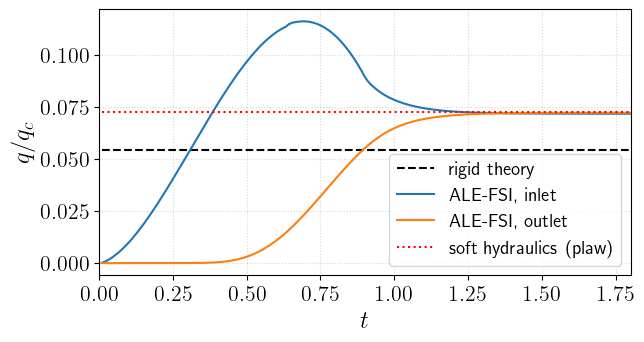

In [417]:
# Create plot:
fig, ax = plt.subplots()
ax.plot(time_array, float(q_rigid/q_c)*np.ones(len(time_array)), 
        label='rigid theory', linestyle='dashed', color='black')

# Signed convention (outward normals): inlet < 0, outlet > 0.
# Nanson-mapped fluxes are the physically meaningful ALE fluxes on moving boundaries.
# ax.plot(time_array, -saved_qs[:,0]/float(q_c), 
#         label=r'ALE-FSI, initial/rigid inlet', color='blue')
ax.plot(time_array, -saved_qs[:,1]/float(q_c), label=r"ALE-FSI, inlet") # Nanson
# ax.plot(time_array, saved_qs[:,2]/float(q_c), 
#         label=r'ALE-FSI, initial/rigid outlet', color='cornflowerblue')
ax.plot(time_array, saved_qs[:,3]/float(q_c), label=r"ALE-FSI, outlet") # Nanson

ax.plot(time_array, float(q_sh/q_c)*np.ones(len(time_array)), 
        label='soft hydraulics (plaw)', linestyle='dotted', color='red')

ax.set_xlabel('$t$')
ax.set_ylabel('$q/q_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, np.round(time_array[-1],2))
#ax.set_ylim(0, float(q_amp))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.tight_layout()
plt.show()

## Height-averaged axial pressure distribution

In [418]:
# Plotting sampling parameters:
num_x_samples = 50
num_y_samples = 100
x_vals = np.linspace(0.0, l, num_x_samples)
y_line = np.linspace(0.0, h0, num_y_samples)

# Cross-sectional averages via line integrals (trapz along y at fixed x).
# More accurate than strip-indicator approach: no area-averaging artifacts,
# no DG0/CG1 indicator mismatch, proper 1/h0 normalization.

p_plot = Function(V_plot)
p_plot.interpolate(p_out)
p_interp = LinearNDInterpolator(plot_coords, p_plot.x.array.real)

xv, yv = np.meshgrid(x_vals, y_line, indexing='ij')
# Boundary interpolation can produce NaN near convex-hull edges; replace with 0
# to prevent artificial truncation of the averaged pressure curve near x=l.
avg_p = trapz(np.nan_to_num(p_interp(xv, yv), nan=0.0), y_line, axis=1) / h0

# Optional axial derivatives via central differences (O(Δx^2) interior):
# avg_dpdx   = np.gradient(avg_p,    x_vals)
# avg_d2pdx2 = np.gradient(avg_dpdx, x_vals)

# Rigid-channel and soft-hydraulic reference pressures:
pressure_rigid = np.array([p_rigid_py(float(xi), 0.0) for xi in x_vals])
pressure_sh    = np.array([p_sh_py(float(xi),    0.0) for xi in x_vals])

Reminder: compliance #, α = 0.17576


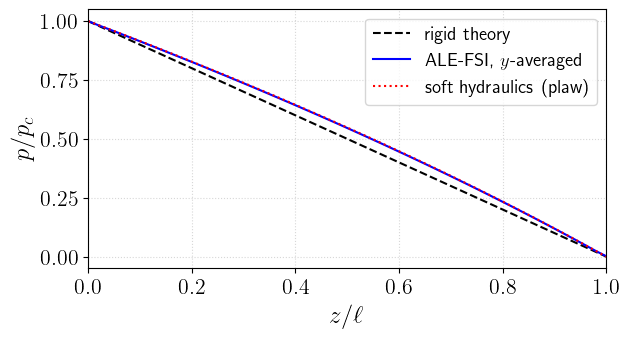

In [419]:
# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, pressure_rigid/float(p_c), 
        label='rigid theory', linestyle='dashed', color='black')
ax.plot(x_vals/l, avg_p/float(p_c), 
        label='ALE-FSI, $y$-averaged', color='blue')
ax.plot(x_vals/l, pressure_sh/float(p_c), 
        label='soft hydraulics (plaw)', linestyle='dotted', color='red')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

print(f"Reminder: compliance #, α = {alpha:.5f}")

plt.show()


## Fluid&ndash;solid interface displacement and pressure

Reminder: compliance #, α = 0.17576


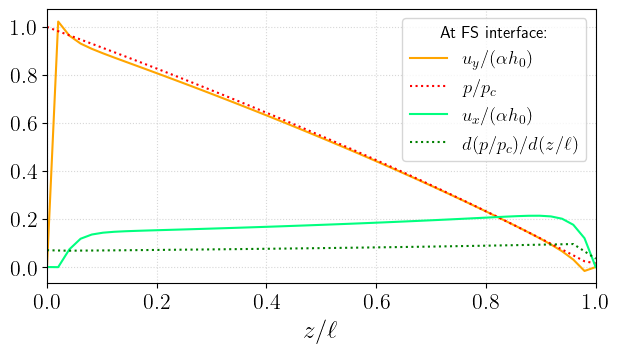

In [420]:
# Interpolators for u components (reuse p_interp from previous cell):
ux_plot = Function(V_plot)
uy_plot = Function(V_plot)
ux_plot.interpolate(Expression(uhat[0], V_plot.element.interpolation_points))
uy_plot.interpolate(Expression(uhat[1], V_plot.element.interpolation_points))
u_interp = LinearNDInterpolator(plot_coords,
                np.column_stack([ux_plot.x.array.real, uy_plot.x.array.real]))

# Create points along the fluid-solid interface:
fs_line_points = np.column_stack([x_vals, np.full_like(x_vals, h0)])

# Evaluate interface fields at collocated points:
uy_fs_values = u_interp(fs_line_points)[:, 1]
ux_fs_values = u_interp(fs_line_points)[:, 0]
p_fs_values  = p_interp(fs_line_points).ravel()
# Axial derivatives amplify pointwise noise; treat dp/dx trends as qualitative
# unless resolution/smoothing studies are performed.
# d/dx and d2/dx2 axial derivatives via central differences, O(Δx²):
dpdx_fs      = np.gradient(p_fs_values, x_vals)
d2pdx2_fs    = np.gradient(dpdx_fs, x_vals)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, uy_fs_values/float(alpha*h0),
        label=r'$u_y/(\alpha h_0)$', color='orange')
ax.plot(x_vals/l, p_fs_values/float(p_c), 
        label='$p/p_c$', color='red', linestyle='dotted')
ax.plot(x_vals/l, ux_fs_values/float(alpha*h0),
        label=r'$u_x/(\alpha h_0)$', color='springgreen')
ax.plot(x_vals/l, -vartheta*dpdx_fs/(float(p_c)/l), 
        label=r'$d(p/p_c)/d(z/\ell)$', color='green', linestyle='dotted')

ax.set_xlabel(r'$z/\ell$')
#ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend(title="At FS interface:", title_fontsize='large')

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

print(f"Reminder: compliance #, α = {alpha:.5f}")

plt.show()

## Pressure contours

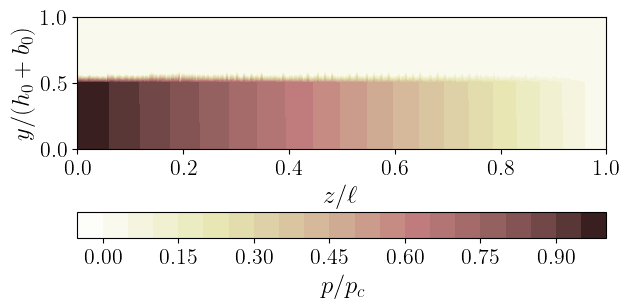

In [421]:
# Get pressure values at vertices (dolfinx-style via V_plot interpolation):
p_plot = Function(V_plot)
p_plot.interpolate(p_out)
pressure_values = p_plot.x.array.real

fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, pressure_values/float(p_c),
                         levels=20, cmap='pink_r')
fig.colorbar(contour, label='$p/p_c$', orientation='horizontal')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

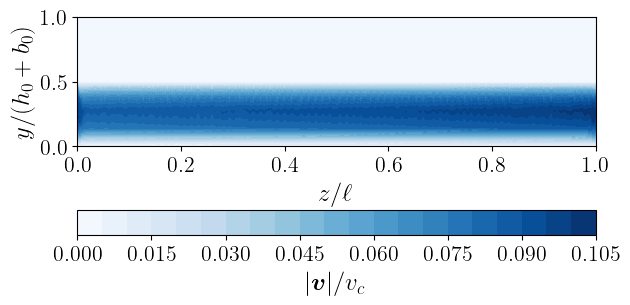

In [422]:
# Get velocity values at vertices (dolfinx-style via V_plot interpolation):
vmag_plot = Function(V_plot)
vmag_expr = Expression(sqrt(dot(v_out, v_out)), V_plot.element.interpolation_points)
vmag_plot.interpolate(vmag_expr)

magnitude = vmag_plot.x.array.real

fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c),
                         levels=20, cmap='Blues')
cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{v}|/v_c$')
else:
    cb.set_label(r'$|\vec{v}|/v_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.tight_layout()
plt.show()

## Displacement magnitude contours

We will mask all $y/h_0 < h_0/(h_0+b_0)$ to show only the displacement field in the solid. There is mesh displacement in the fluid domain but we do not consider that to be "physical."

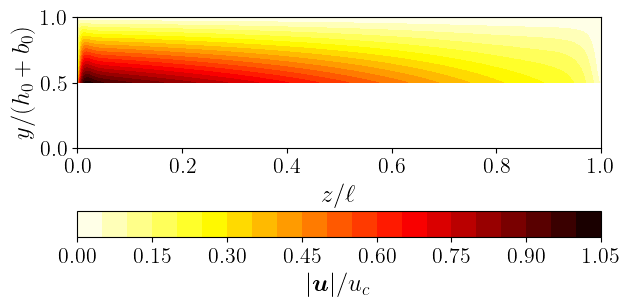

In [423]:
umag_plot = Function(V_plot)
umag_expr = Expression(sqrt(dot(uhat, uhat)), V_plot.element.interpolation_points)
umag_plot.interpolate(umag_expr)

magnitude = umag_plot.x.array.real

# Mask off fluid domain; deep-copy triangulation arrays before masking.
masked_triang = tri.Triangulation(x_coords.copy(), y_coords.copy(), plot_cells.copy())
masked_triang.set_mask(
    np.mean(y_coords[masked_triang.triangles], axis=1) < h0/(h0+b0))

fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(masked_triang, magnitude/float(alpha*h0),
                         levels=20, cmap='hot_r')

cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{u}|/u_c$')
else:
    cb.set_label(r'$|\vec{u}|/u_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()